# Projeto: Predição de Churn em Telecomunicações

**Dataset:** [Telco Customer Churn - Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

## Descrição do Problema e dos Dados

### Contexto

A indústria de telecomunicações enfrenta alta competitividade e custos de aquisição de novos clientes significativamente maiores que os de retenção. O **churn** - cancelamento voluntário do serviço - representa perda direta de receita recorrente. Prever quais clientes estão em risco de cancelar permite que a empresa adote ações preventivas (descontos, planos personalizados, melhor atendimento), tornando o modelo preditivo um instrumento estratégico.

### Por que Machine Learning?

Regras fixas baseadas em experiência capturam apenas padrões simples. A decisão de cancelar envolve interações não lineares entre múltiplas variáveis - tipo de contrato, tempo de cliente, serviços contratados, perfil demográfico - que modelos supervisionados aprendem de forma sistemática e escalável.

### Desafios do Domínio

- **Desbalanceamento de classes:** taxa de churn (~26%) menor que a de retenção (~74%), o que pode fazer modelos privilegiarem a classe majoritária.
- **Custo assimétrico de erros:** falso negativo (não detectar churn real) é tipicamente mais custoso que falso positivo.
- **Variáveis categóricas:** a maioria das features descreve atributos contratuais e de serviço, exigindo codificação adequada.

### Dataset

| Atributo | Valor |
|---|---|
| Origem | IBM Sample Data / Kaggle |
| Observações | 7.043 clientes |
| Features utilizáveis | 19 (4 numéricas + 15 categóricas) |
| Variável-alvo | `Churn` (Sim/Não) - classificação binária |

**Variável-alvo:** `Churn` indica se o cliente cancelou o serviço no último mês. É binária por natureza e define o problema como classificação supervisionada binária (1 = cancelou, 0 = manteve).

**Features numéricas:** `SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`

**Features categóricas:** tipo de contrato, serviços contratados (internet, suporte técnico, streaming), método de pagamento, dados demográficos, entre outros. Sua inclusão é justificada por serem atributos centrais na decisão de cancelamento - tipo de contrato e método de pagamento demonstram forte correlação com churn na literatura de telco.

In [1]:
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
)
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

d:\repos\intro-ml-infnet\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ['KAGGLEHUB_CACHE'] = os.path.abspath('')

# download do dataset via kagglehub
path = kagglehub.dataset_download('blastchar/telco-customer-churn')
csv_path = os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

data = pd.read_csv(csv_path)
data.head()

100%|██████████| 172k/172k [00:00<00:00, 627kB/s]

Extracting files...


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Análise Exploratória

In [36]:
print(f'Shape: {data.shape}')
print('\nTipos de dados:')
data.info()

Shape: (7043, 21)

Tipos de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperle

In [37]:
print(f"Total de clientes únicos: {data['customerID'].nunique()}")

Total de clientes únicos: 7043


In [38]:
# TotalCharges apesar de aparentar ser númerico está aparecendo como object, possível valor inesperado para a coluna
# verificando valores únicos da coluna
print(f"TotalCharges únicos: {data['TotalCharges'].nunique()}") # 6531 de 7043 

# verificando a quantidade de valores não numéricos na coluna
print(f"TotalCharges não numéricos: {data[pd.to_numeric(data['TotalCharges'], errors='coerce').isna()]['TotalCharges'].count()}")

TotalCharges únicos: 6531
TotalCharges não numéricos: 11


In [39]:
# Convertendo TotalCharges para numérico
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# verificar valores ausentes
print('Valores ausentes:')
display(data.isna().sum()[data.isna().sum() > 0])

# distribuição da classe-alvo
print('\nDistribuição do Churn:')
display(data['Churn'].value_counts(normalize=True).round(3))

Valores ausentes:


TotalCharges    11
dtype: int64


Distribuição do Churn:


Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [41]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## Pré-Processamento dos Dados

In [42]:
# remover customerID que é só identificador
data = data.drop(columns=['customerID'])

# codificar target: Yes -> 1, No -> 0
data['Churn'] = (data['Churn'] == 'Yes').astype(int)

# definir features e target
TARGET = 'Churn'
NUM_FEATURES = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
CAT_FEATURES = [c for c in data.columns if c != TARGET and c not in NUM_FEATURES]

print(f'Features numéricas ({len(NUM_FEATURES)}): {NUM_FEATURES}')
print(f'Features categóricas ({len(CAT_FEATURES)}): {CAT_FEATURES}')
print(f'Total de features: {len(NUM_FEATURES) + len(CAT_FEATURES)}')

Features numéricas (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Features categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Total de features: 19


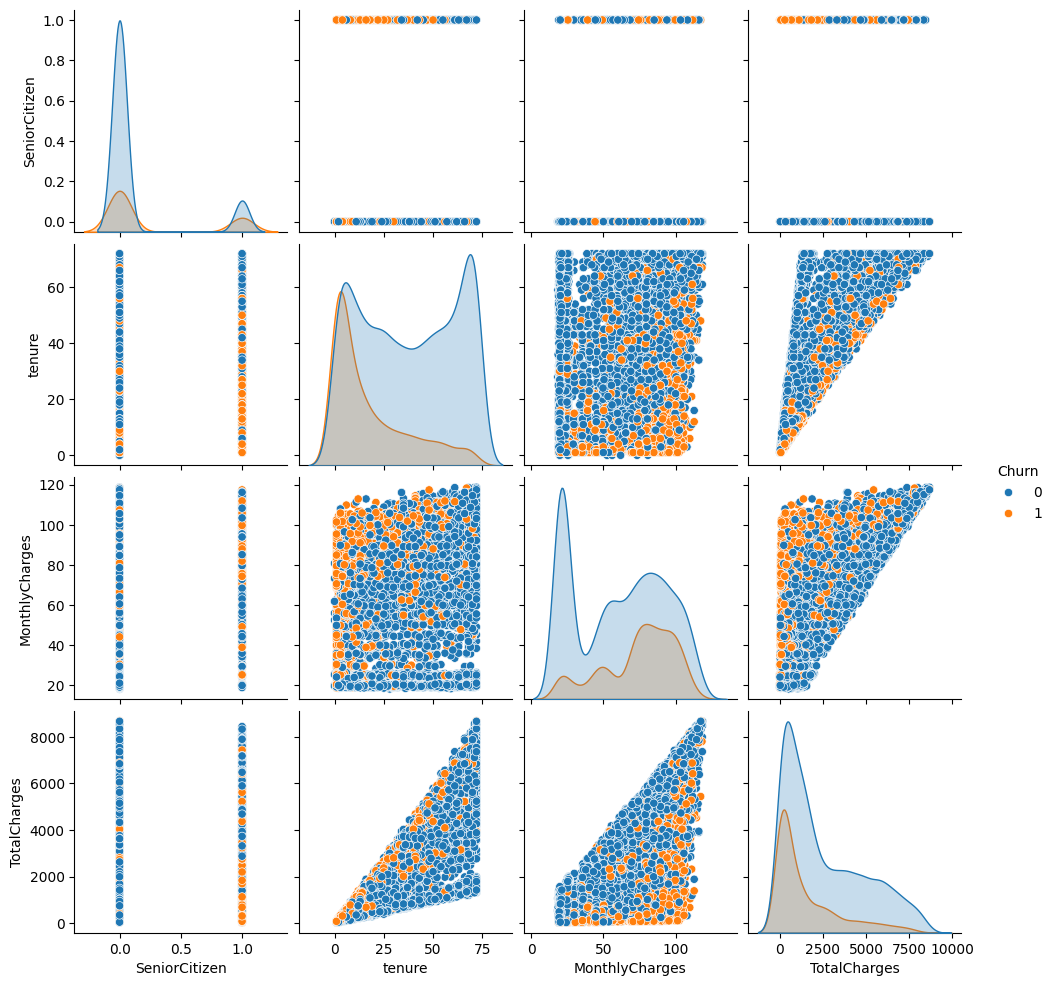

In [43]:
sns.pairplot(data=data.iloc[:, 1:], hue='Churn')

plt.show()

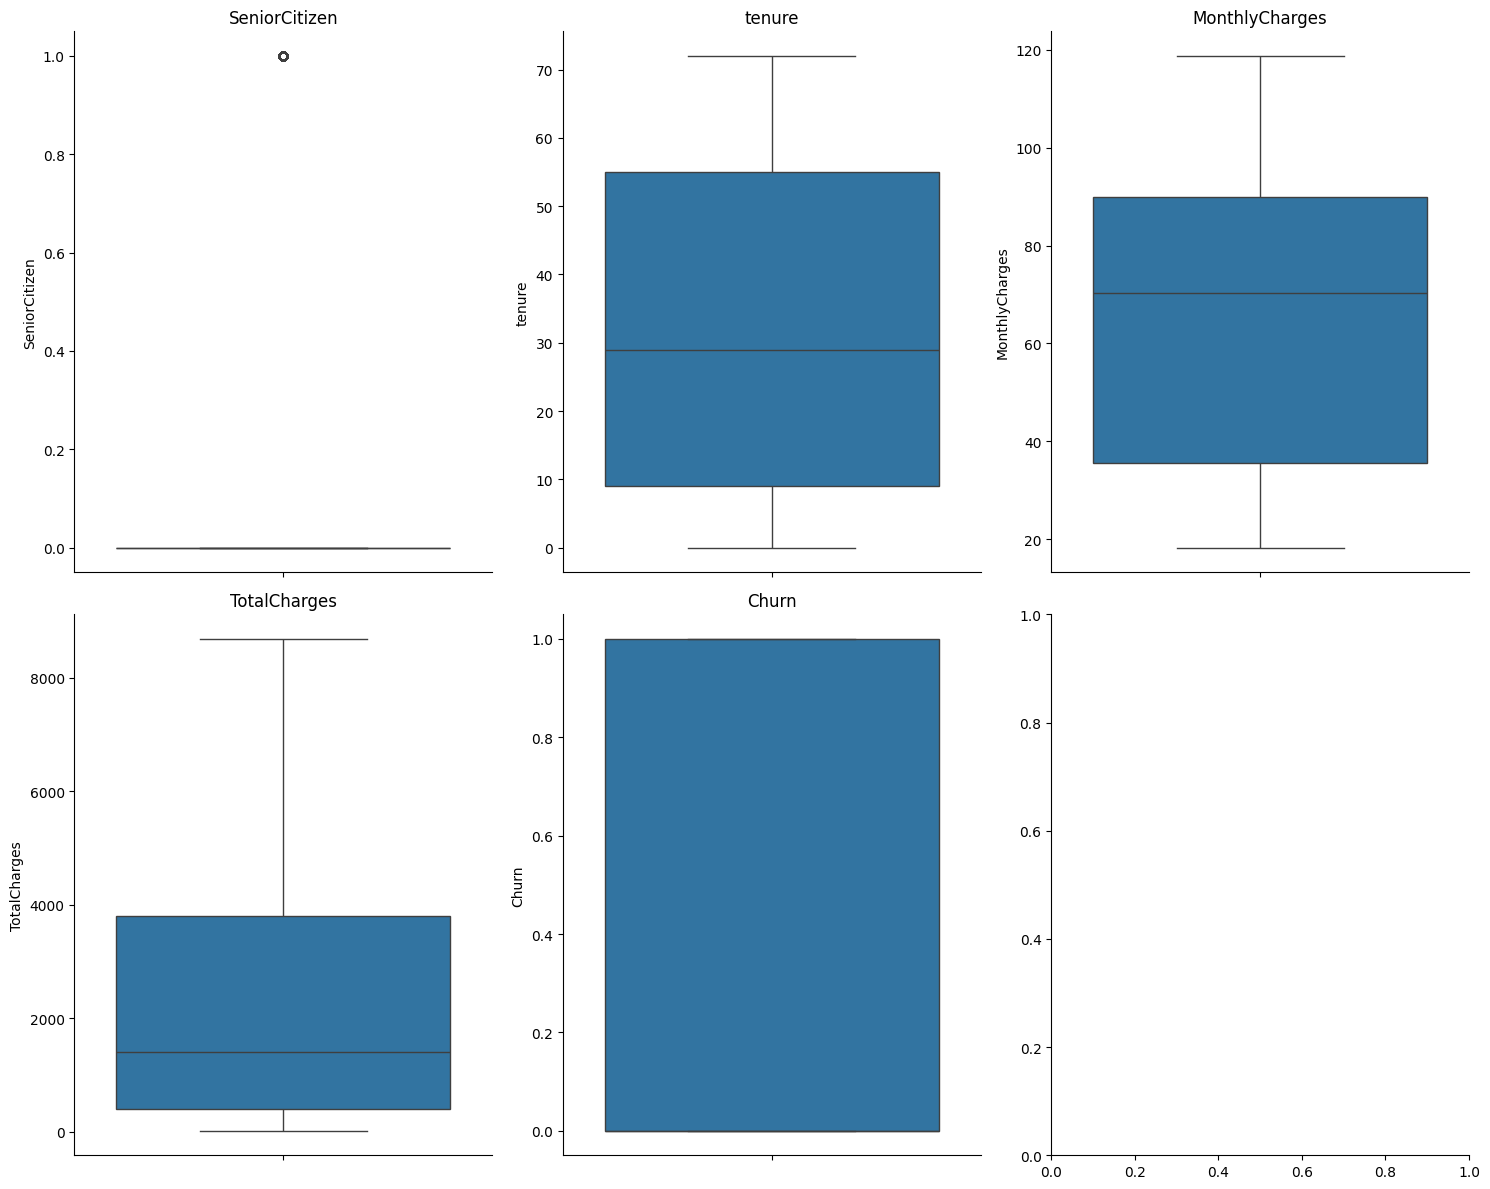

In [44]:
numeric_cols = data.select_dtypes(include='number').columns
n_cols = len(numeric_cols)

f, ax = plt.subplots(2, 3, figsize=(15, 12))
ax = ax.flatten()

for i, column in enumerate(numeric_cols):
    sns.boxplot(data=data, y=column, ax=ax[i])
    ax[i].set_title(column)

sns.despine()
plt.tight_layout()
plt.show()

Mais abaixo foi utilizado o SimpleImputer para preencher os valores ausentes que estão como NaN na coluna TotalCharges com a mediana, e o RobustScaler para escalar os valores numéricos em um mesmo intervalo, esse scaler foi escolhido por ser mais robusto a outliers.

Também foi utilizado o OneHotEncoder para as variáveis categóricas as vetorizando e eliminando uma coluna para evitar multicolinearidade, para então utilizar o ColumnTransformer e resolver o problema de vazamento de dados entre as variáveis numéricas e vetorizadas.

In [45]:
x = data.drop(columns=[TARGET])
y = data[[TARGET]]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_transformer = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer([
    ('num', num_transformer, NUM_FEATURES),
    ('cat', cat_transformer, CAT_FEATURES)
])

print(f'Treino: {x_train.shape[0]} amostras | Teste: {x_test.shape[0]} amostras')

Treino: 4930 amostras | Teste: 2113 amostras


## Modelo Baseline: Perceptron

O Perceptron é o classificador linear mais simples, pois aprende um hiperplano separador no espaço das features, tomando decisões com base no sinal de uma combinação linear ponderada das entradas:

ŷ = w₀ + w₁x₁ + w₂x₂ + … + wₙxₙ

- Classe positiva (churn) se $\hat{y} \geq 0$
- Classe negativa (nao churn) se $\hat{y} < 0$


In [46]:
pipeline_perceptron = Pipeline([
    ('preprocessor', preprocessor),
    ('perceptron', Perceptron(random_state=RANDOM_STATE, max_iter=1000))
])

pipeline_perceptron.fit(x_train, y_train.values.ravel())

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('perceptron', Perceptron(random_state=42))])

In [47]:
def evaluate(y_tr, y_te, yhat_tr, yhat_te, name='Modelo'):
    print(f'=== {name} ===')
    print('Treinamento:')
    print(classification_report(y_tr, yhat_tr, zero_division=0))
    print('Teste:')
    print(classification_report(y_te, yhat_te, zero_division=0))

yhat_train_perc = pipeline_perceptron.predict(x_train)
yhat_test_perc  = pipeline_perceptron.predict(x_test)

evaluate(
    y_train.values.ravel(), y_test.values.ravel(),
    yhat_train_perc, yhat_test_perc,
    'Perceptron Baseline'
)

=== Perceptron Baseline ===
Treinamento:
              precision    recall  f1-score   support

           0       0.89      0.61      0.73      3622
           1       0.42      0.78      0.55      1308

    accuracy                           0.66      4930
   macro avg       0.65      0.70      0.64      4930
weighted avg       0.76      0.66      0.68      4930

Teste:
              precision    recall  f1-score   support

           0       0.87      0.61      0.72      1552
           1       0.41      0.75      0.53       561

    accuracy                           0.65      2113
   macro avg       0.64      0.68      0.63      2113
weighted avg       0.75      0.65      0.67      2113



Aqui é possível perceber que o desbalanceamento entre as classes e a linearidade do modelo afeta os resultados, deixando o ele muito mais preciso na identificação da classe majoritária e muito menos preciso na identificação da classe minoritária.

Bias (w0): -3.0000

Top 15 coeficientes por magnitude absoluta:
tenure                                  -6.8298
Contract_Two year                       -5.0000
TotalCharges                             4.0191
MultipleLines_Yes                        4.0000
DeviceProtection_Yes                     4.0000
Contract_One year                       -3.0000
PaperlessBilling_Yes                     3.0000
InternetService_Fiber optic              2.0000
OnlineBackup_No internet service        -2.0000
StreamingTV_No internet service         -2.0000
OnlineSecurity_No internet service      -2.0000
SeniorCitizen                            2.0000
PhoneService_Yes                        -2.0000
InternetService_No                      -2.0000
PaymentMethod_Credit card (automatic)    2.0000
dtype: float64


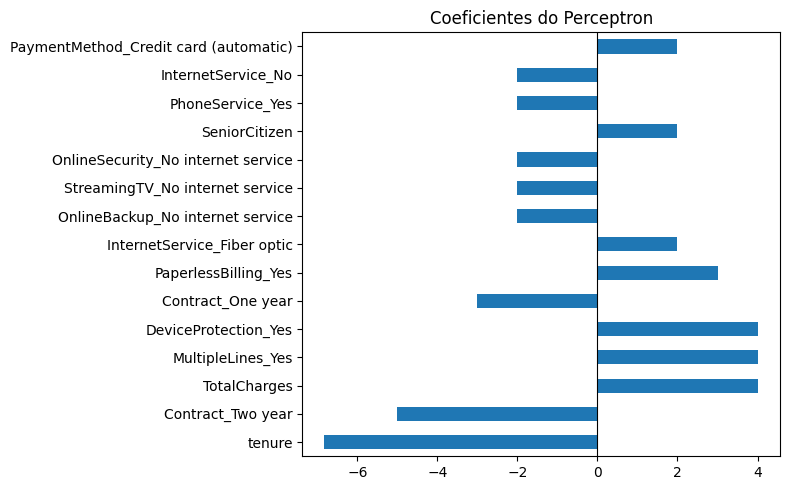

In [48]:
cat_names_perc = list(
    pipeline_perceptron['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(CAT_FEATURES)
)
all_feature_names = NUM_FEATURES + cat_names_perc

# coeficientes e bias
coefs = pd.Series(
    pipeline_perceptron['perceptron'].coef_[0],
    index=all_feature_names
).sort_values(key=abs, ascending=False)

bias = pipeline_perceptron['perceptron'].intercept_[0]
print(f'Bias (w0): {bias:.4f}')
print('\nTop 15 coeficientes por magnitude absoluta:')
print(coefs.head(15).round(4))

coefs.head(15).plot(kind='barh', figsize=(8, 5), title='Coeficientes do Perceptron')
plt.axvline(0, color='k', linewidth=0.8)
plt.tight_layout()
plt.show()

### Interpretação do Perceptron

O hiperplano aprendido é definido por $\hat{y} = w_0 + \mathbf{w}^\top\mathbf{x}$, onde cada coeficiente $w_i$ indica a contribuição da feature $x_i$ para a decisão de classificação:
- **Bias $w_0$:** com o valor obtido -3.0, desloca o hiperplano para não-churn, tendendo a classificar mais instâncias como não-churn muito por conta da distribuição maior dessa classe do que a positiva. Isso faz com que o a classificação como churn fique mais difícil já que precisaria compensar o bias.
- **Coeficientes positivos** ($w_i > 0$): features que elevam a pontuação em direção ao churn: custos altos acumulados (TotalCharges), contratos mensais ou com muitos serviços extras (com destaque para fibra ótica), fatura digital e pessoa com idade avançada. Dessa forma é possível perceber que o custo elevado por serviços extras (o que também pode sugerir insatisfação com esses serviços) são a causa principal de cancelamentos.
- **Coeficientes negativos** ($w_i < 0$): features que mais apontam para não-churn: tempo de utilização do serviço (tenure), contrato de 1 ano ou mais e clientes que não possuem serviços de internet. Interpretando esses coeficientes faz sentido que os clientes que estão a mais tempo e os clientes que fazem contratos novos mais longos não cancelem o serviço.

### Limitações

- **Separabilidade linear:** o Perceptron só converge se os dados forem linearmente separáveis, o que raramente satisfaz essa premissa.
- **Sensibilidade a ruído e outliers:** sem margem de segurança, um único ponto mal classificado pode alterar o hiperplano significativamente.
- **Underfitting na classe minoritária:** o recall de churn (classe 1) tende a ser baixo dado o desbalanceamento.
- **Ausência de probabilidade:** a saída binária impede calibração de risco, limitando seu uso em tomada de decisão mais granular.

## Árvore de Decisão

A árvore de decisão supera a limitação de linearidade do Perceptron ao aprender **regras hierárquicas** baseadas em valores de corte das features. Cada  nó interno divide o espaço de features ortogonalmente, cada folha define uma classe prevista. Iniciamos com parametros padrão para observar o comportamento natural do algoritmo.

In [49]:
preprocessor_tree = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), NUM_FEATURES),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
])

pipeline_dt = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

pipeline_dt.fit(x_train, y_train.values.ravel())

yhat_train_dt = pipeline_dt.predict(x_train)
yhat_test_dt  = pipeline_dt.predict(x_test)

evaluate(
    y_train.values.ravel(), y_test.values.ravel(),
    yhat_train_dt, yhat_test_dt,
    'Arvore de Decisão (parâmetros padrão)'
)

=== Arvore de Decisão (parâmetros padrão) ===
Treinamento:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3622
           1       1.00      0.99      1.00      1308

    accuracy                           1.00      4930
   macro avg       1.00      1.00      1.00      4930
weighted avg       1.00      1.00      1.00      4930

Teste:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1552
           1       0.49      0.50      0.50       561

    accuracy                           0.73      2113
   macro avg       0.66      0.66      0.66      2113
weighted avg       0.73      0.73      0.73      2113



Aqui temos overfitting, explícito no treinamento onde quase tudo resultou em 1.0 e em teste tivemos uma grande variância nos resultados, mostrando que o modelo memorizou o treino e não aprendeu com ele.

Profundidade da árvore: 25
Número de folhas: 967


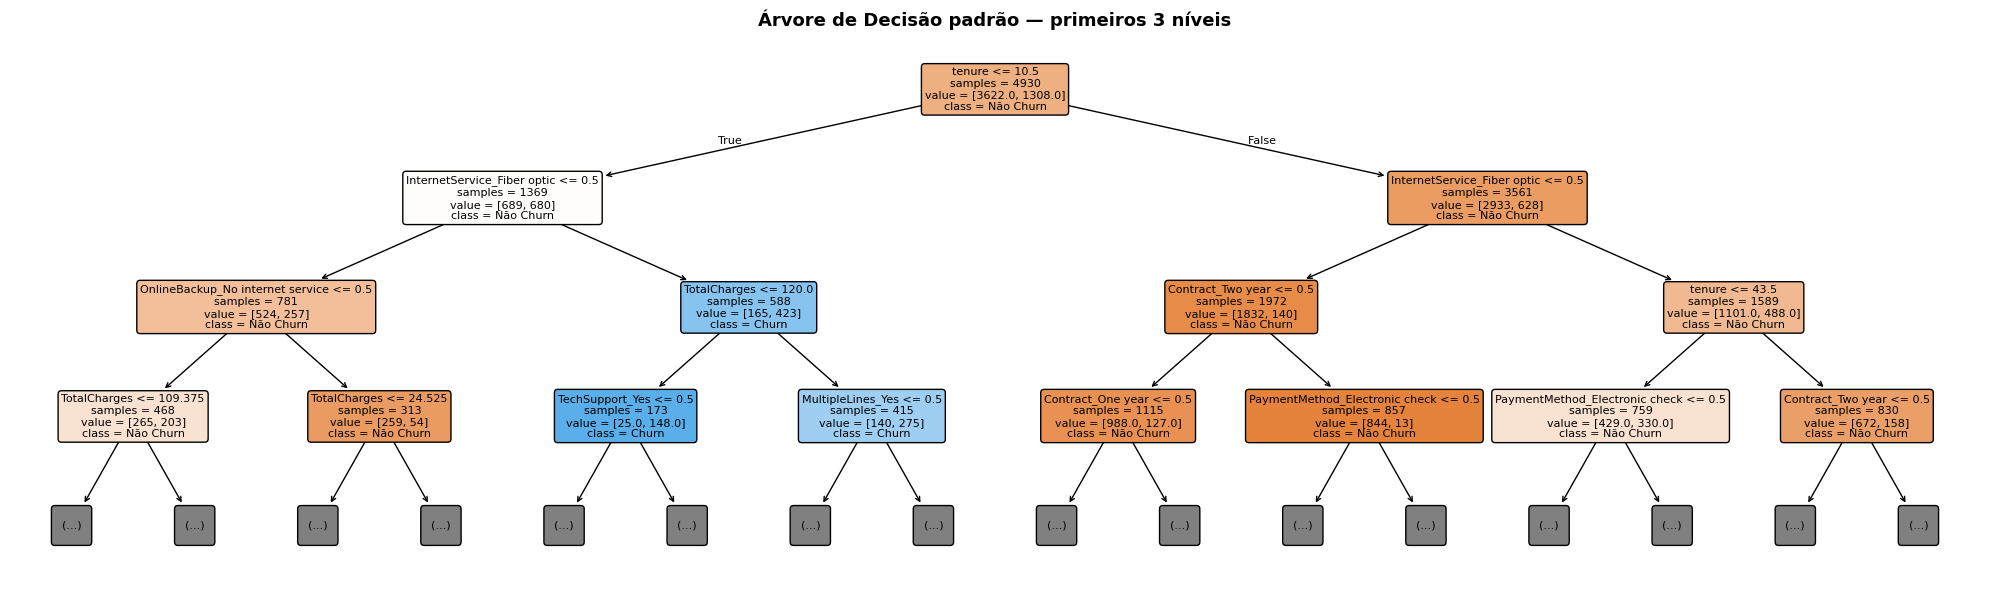

In [50]:
dt_model = pipeline_dt['dt']
print(f'Profundidade da árvore: {dt_model.get_depth()}')
print(f'Número de folhas: {dt_model.get_n_leaves()}')

cat_names_tree = list(
    pipeline_dt['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(CAT_FEATURES)
)
all_feat_names = NUM_FEATURES + cat_names_tree

# primeiros 3 níveis via plot_tree
plt.figure(figsize=(20, 6))
plot_tree(
    dt_model,
    feature_names=all_feat_names,
    class_names=['Não Churn', 'Churn'],
    filled=True,
    max_depth=3,
    fontsize=8,
    impurity=False,
    rounded=True
)
plt.title('Árvore de Decisão padrão — primeiros 3 níveis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análise da Árvore de Decisão

**Comparação com o Perceptron:**
- A árvore aprende fronteiras não lineares (divisões ortogonais por feature), capturando padrões que o Perceptron não consegue representar ou separar.
- Apesar disso, nesse caso por conta do overfitting, a árvore sem bons hiperparâmetros não conseguiu um bom desempenho no teste ficando abaixo do recall do Perceptron.
- As features próximas da raiz são as mais discriminativas (ex.: tipo de contrato, tenure).

**Risco de overfitting:**
- Com parâmetros padrão, a árvore cresce sem restrição de profundidade, memorizando o conjunto de treino (accuracy ~1.0 no treino).
- A queda expressiva de desempenho no teste evidência que o modelo capturou ruído específico dos dados de treinamento.
- Profundidade elevada e muitas folhas tornam o modelo difícil de interpretar e de explicar.

## Validação Cruzada e Busca de Hiperparâmetros

Como diagnosticado na etapa anterior, a Árvore de Decisão padrão sofreu overfitting (decorou os dados de treino ao invés de aprender os padrões gerais).

Para tratar esse problema, precisamos "frear" o crescimento da árvore, testando diferentes configurações.

Para encontrar a configuração ideal, utilizamos o Grid Search em conjunto com a Validação Cruzada Estratificada (k=5). A estratificação foi essencial para garantir que cada um dos 5 testes mantivesse a mesma proporção de clientes com e sem churn da base original.

A escolha do Grid Search se justifica pelo teste de todas as combinações de parâmetros. Como o nosso espaço de busca é pequeno (cerca de 40 combinações), o custo computacional é muito baixo. Isso torna o Grid Search a ferramenta ideal, pois ele nos garante encontrar a melhor configuração dentro das opções dadas, sem a necessidade de recorrer a buscas aleatórias (como o Random Search), que só seriam preferíveis se tivéssemos milhares de combinações.

**Hiperparâmetros otimizados**: Para forçar o modelo a generalizar melhor, focamos em três parâmetros principais:

- **max_depth** (profundidade máxima): Atua como o principal mecanismo de regularização. Ao limitar o número de "perguntas" que a árvore pode fazer, impedimos que ela crie regras excessivamente específicas para clientes individuais.

- **min_samples_leaf** (amostras por folha): Controla a granularidade do modelo. Ao exigir um número mínimo de clientes em cada folha final, garantimos que as regras aprendidas sejam baseadas em grupos representativos, e não em casos isolados (ruído), evitando folhas com apenas 1 cliente.

- **criterion** (critério de impureza): Testamos as métricas matemáticas gini e entropy para definir qual delas faria as melhores quebras nos dados na hora de separar os clientes propensos ao churn.

In [51]:
pipe_cv = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), NUM_FEATURES),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
    ])),
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    'dt__criterion':        ['gini', 'entropy'],
    'dt__max_depth':        [3, 5, 7, 10, 12],
    'dt__min_samples_leaf': [1, 5, 10, 20]
}

splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=pipe_cv,
    param_grid=param_grid,
    scoring='f1',
    cv=splitter,
    refit=True,
    n_jobs=-1
)

grid_search.fit(x_train, y_train.values.ravel())

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         SimpleImputer(strategy='median'),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dep...
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('dt',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'dt__criterion': ['gini', 'entropy'],
                         'dt__max_depth': [3, 5, 7, 10, 12],
                         'dt__min_samples_leaf': [1, 5, 10, 20]},
             scoring='f1')

In [52]:
print('Melhores hiperparâmetros:', grid_search.best_params_)
print(f'Melhor F1 médio (CV): {grid_search.best_score_:.4f}')

# variação do F1 entre os folds para o melhor modelo
best_idx = grid_search.best_index_
fold_scores = [
    grid_search.cv_results_[f'split{i}_test_score'][best_idx]
    for i in range(5)
]
print(f'\nF1 por fold: {[round(s, 4) for s in fold_scores]}')
print(f'Desvio padrão entre folds: {np.std(fold_scores):.4f}')

Melhores hiperparâmetros: {'dt__criterion': 'entropy', 'dt__max_depth': 7, 'dt__min_samples_leaf': 10}
Melhor F1 médio (CV): 0.5951

F1 por fold: [np.float64(0.572), np.float64(0.5961), np.float64(0.5824), np.float64(0.6008), np.float64(0.6241)]
Desvio padrão entre folds: 0.0177


In [53]:
yhat_train_opt = grid_search.best_estimator_.predict(x_train)
yhat_test_opt  = grid_search.best_estimator_.predict(x_test)

evaluate(
    y_train.values.ravel(), y_test.values.ravel(),
    yhat_train_opt, yhat_test_opt,
    'Árvore Otimizada (GridSearch)'
)

dt_opt = grid_search.best_estimator_['dt']
print(f'Profundidade: {dt_opt.get_depth()} | Folhas: {dt_opt.get_n_leaves()}')

=== Árvore Otimizada (GridSearch) ===
Treinamento:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      3622
           1       0.66      0.60      0.63      1308

    accuracy                           0.81      4930
   macro avg       0.76      0.74      0.75      4930
weighted avg       0.81      0.81      0.81      4930

Teste:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1552
           1       0.61      0.55      0.58       561

    accuracy                           0.79      2113
   macro avg       0.72      0.71      0.72      2113
weighted avg       0.78      0.79      0.78      2113

Profundidade: 7 | Folhas: 72


In [54]:
dt_opt_model = grid_search.best_estimator_['dt']

cat_names_opt = list(
    grid_search.best_estimator_['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(CAT_FEATURES)
)
all_feat_names_opt = NUM_FEATURES + cat_names_opt

print(f'Profundidade: {dt_opt_model.get_depth()} | Folhas: {dt_opt_model.get_n_leaves()}')
print('\nRegras — primeiros 3 níveis:')
print(export_text(dt_opt_model, feature_names=all_feat_names_opt, max_depth=3))


Profundidade: 7 | Folhas: 72

Regras — primeiros 3 níveis:
|--- Contract_Two year <= 0.50
|   |--- Contract_One year <= 0.50
|   |   |--- InternetService_Fiber optic <= 0.50
|   |   |   |--- tenure <= 3.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- tenure >  3.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- InternetService_Fiber optic >  0.50
|   |   |   |--- tenure <= 14.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- tenure >  14.50
|   |   |   |   |--- truncated branch of depth 4
|   |--- Contract_One year >  0.50
|   |   |--- StreamingMovies_Yes <= 0.50
|   |   |   |--- PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- StreamingMovies_Yes >  0.50
|   |   |   |--- PaperlessBilling_Yes <= 0.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- PaperlessBil

### Análise da Validação Cruzada

**1. Generalização e Redução do Overfitting:** A otimização foi bem-sucedida em estabilizar o modelo. A queda de desempenho entre os dados de treinamento e teste foi reduzida (acurácia de 0.81 para 0.79 e F1-Score da classe 1 de 0.63 para 0.58). Isso confirma que a árvore parou de memorizar e aprendeu padrões generalizáveis.

**2. Impacto da Regularização na Estrutura:** Os hiperparâmetros restringiram a complexidade do modelo a uma profundidade máxima de 7 e apenas 72 folhas.
O max_depth atuou como um freio de crescimento, evitando regras infinitas.
O min_samples_leaf garantiu que cada uma dessas 72 folhas contivesse um grupo representativo de clientes, bloqueando regras feitas para casos isolados.

**3. Robustez (Validação Cruzada):** O baixo desvio padrão (<0.02) da métrica F1 entre os folds comprova a estabilidade do modelo. Ele não teve um resultado "fácil" por sorte na separação dos dados, o desempenho é consistente independentemente do subconjunto utilizado no treino.

**4. Desempenho no Negócio (Classe Churn):** Apesar do ganho em generalização, o modelo apresenta um Recall moderado (0.55 no teste) para a classe alvo (Churn=1). Isso evidencia o viés natural do modelo em direção à classe majoritária (não-churn) e indica que a árvore, mesmo otimizada, atinge um limite de performance devido ao desbalanceamento original dos dados.

**5. Interpretabilidade:** Com apenas 7 níveis estruturais, as lógicas de corte (fronteiras de decisão) permanecem rastreáveis. É viável auditar o modelo e extrair o caminho das regras que definem os perfis de clientes de alto risco para a área de negócios.

## Modelo Avançado: Random Forest

O **Random Forest** é um ensemble de árvores de decisão treinadas em subamostras aleatórias (bagging) com subconjuntos aleatórios de features a cada divisão. A predição final é por **votação majoritária**.

**Vantagens e motivo da escolha:**
- Reduz variância via bagging (notado anteriormente), diversidade entre árvores diminui o erro de generalização.
- Mais robusto a outliers e ruído do que árvores individuais.
- Importância de features nativa, sem necessidade de ferramentas externas de explicabilidade. É possível interpretar e mostrar as regras, importante para esse tipo de domínio.

Aplicamos **Random Search** por ser mais eficiente quando o espaço de hiperparâmetros é amplo: amostramos 20 combinações aleatórias em vez de testar todas exaustivamente (maior custo computacional do ensemble). Ao contrário do uso anterior do Grid Search para uma única árvore, agora no Random Forest temos mais árvores, tornando o seu uso mais custoso.

In [55]:
pipe_rf = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), NUM_FEATURES),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
    ])),
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE))
])

param_dist = {
    'rf__n_estimators':    [100, 200, 300],
    'rf__max_depth':       [5, 10, 15, 20],
    'rf__min_samples_leaf': [1, 5, 10],
    'rf__max_features':    ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=splitter,
    refit=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(x_train, y_train.values.ravel())

print('Melhores hiperparâmetros:', random_search.best_params_)
print(f'Melhor F1 médio: {random_search.best_score_:.4f}')

Melhores hiperparâmetros: {'rf__n_estimators': 100, 'rf__min_samples_leaf': 1, 'rf__max_features': 'sqrt', 'rf__max_depth': 10}
Melhor F1 médio: 0.5798


In [56]:
yhat_train_rf = random_search.best_estimator_.predict(x_train)
yhat_test_rf  = random_search.best_estimator_.predict(x_test)

evaluate(
    y_train.values.ravel(), y_test.values.ravel(),
    yhat_train_rf, yhat_test_rf,
    'Random Forest'
)

=== Random Forest ===
Treinamento:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      3622
           1       0.82      0.67      0.74      1308

    accuracy                           0.87      4930
   macro avg       0.85      0.81      0.83      4930
weighted avg       0.87      0.87      0.87      4930

Teste:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1552
           1       0.65      0.50      0.57       561

    accuracy                           0.80      2113
   macro avg       0.74      0.70      0.72      2113
weighted avg       0.78      0.80      0.79      2113



Top 15 features mais importantes:
tenure                                  0.1857
TotalCharges                            0.1574
MonthlyCharges                          0.1177
InternetService_Fiber optic             0.0674
Contract_Two year                       0.0563
PaymentMethod_Electronic check          0.0528
OnlineSecurity_Yes                      0.0377
Contract_One year                       0.0328
TechSupport_Yes                         0.0263
PaperlessBilling_Yes                    0.0251
OnlineBackup_Yes                        0.0180
DeviceProtection_No internet service    0.0176
gender_Male                             0.0167
MultipleLines_Yes                       0.0164
Partner_Yes                             0.0164
dtype: float64


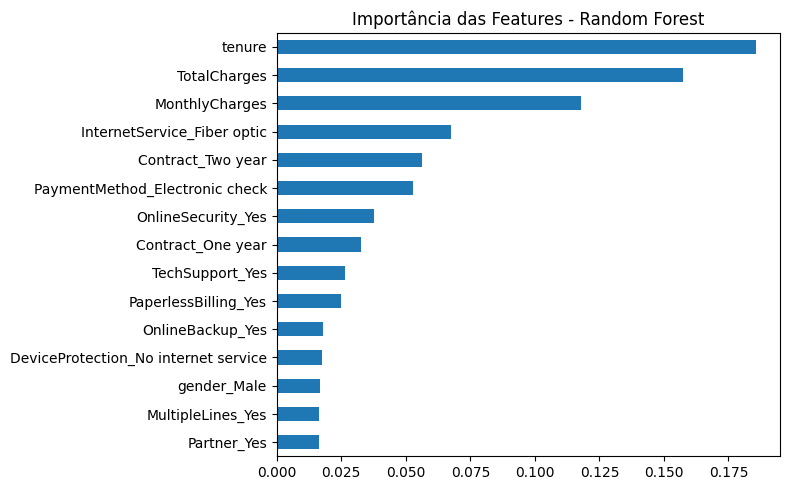

In [57]:
# importância das features
cat_names_rf = list(
    random_search.best_estimator_['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(CAT_FEATURES)
)
feat_names_rf = NUM_FEATURES + cat_names_rf

importances = pd.Series(
    random_search.best_estimator_['rf'].feature_importances_,
    index=feat_names_rf
).sort_values(ascending=False)

print('Top 15 features mais importantes:')
print(importances.head(15).round(4))

importances.head(15).plot(
    kind='barh', figsize=(8, 5),
    title='Importância das Features - Random Forest'
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [58]:
# comparação de todos os modelos no conjunto de teste
def get_metrics(y_true, y_pred):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_true, y_pred, zero_division=0), 4)
    }

y_test_arr = y_test.values.ravel()

results = pd.DataFrame({
    'Perceptron':         get_metrics(y_test_arr, yhat_test_perc),
    'Árvore padrão':   get_metrics(y_test_arr, yhat_test_dt),
    'Árvore otimizada': get_metrics(y_test_arr, yhat_test_opt),
    'Random Forest':      get_metrics(y_test_arr, yhat_test_rf)
}).T

print('=== Comparação de Modelos - Conjunto de Teste ===')
display(results)

=== Comparação de Modelos - Conjunto de Teste ===


,Accuracy,Precision,Recall,F1-Score
Perceptron,0.6507,0.4132,0.7504,0.5329
Árvore padrão,0.7312,0.4938,0.4991,0.4965
Árvore otimizada,0.7861,0.6071,0.5508,0.5776
Random Forest,0.7956,0.6483,0.5027,0.5663


## Discussão Aplicada

### Resultados

A análise das métricas revela que o ganho de complexidade dos modelos alterou a forma como eles lidam com o desbalanceamento da base de dados. O Random Forest alcançou o melhor desempenho em Acurácia (0.7956) e Precisão (0.6483). No entanto, ele não superou os modelos mais simples na captura da classe alvo.

Neste domínio de negócio de Telecomunicações, o Recall é a métrica prioritária: o custo de um falso negativo (não identificar um cliente que vai cancelar) é a perda real da receita recorrente, sendo mais caro do que o custo de uma ação de retenção gasta em um falso positivo. Sob essa ótica:
O Perceptron atingiu o maior Recall (0.7504), agindo como um "alarme sensível". Porém, sua baixíssima precisão (0.4132) significa que ele gera muitos falsos positivos, o que custaria caro em campanhas de retenção desnecessárias.

A Árvore Otimizada, por sua vez, demonstrou ser o modelo mais equilibrado para o negócio. Ela obteve o melhor F1-Score (0.5776) de todo o experimento, oferecendo o ponto ótimo entre não perder tantos clientes em risco (Recall de 0.5508) e não gastar excessivamente com clientes seguros (Precisão de 0.6071).

### Viabilidade no Contexto Real

- O modelo pode ser integrado a sistemas CRM para scoring mensal de clientes em risco.
- Features com interpretação direta permitem que equipes de negócio entendam e confiem nas previsões.
- Tempo de inferência adequado para determinar em lote, diariamente ou semanalmente, os clientes com maior propensão a cancelar.

### Limitações Técnicas e Operacionais

- **Desbalanceamento não tratado:** `class_weight='balanced'` ou SMOTE poderiam melhorar o recall.
- **Dados estáticos:** o dataset é um snapshot mensal, features temporais seriam mais informativas em produção.
- **TotalCharges:** correlação elevada com tenure pode introduzir redundância, embora árvores sejam robustas a multicolinearidade.

### Melhorias

- Aplicar `class_weight='balanced'` para lidar explicitamente com o desbalanceamento.
- Explorar Gradient Boosting (XGBoost, LightGBM) para maior poder preditivo.
- Implementar calibração de probabilidades para decisões baseadas em score de risco graduado.
- Aplicar redução de dimensionalidade (PCA) nas features categóricas codificadas.

## Melhoria no balanceamento de classes

In [59]:
# ── Perceptron com balanceamento ──────────────────────────────────
pipeline_perc_bal = Pipeline([
    ('preprocessor', preprocessor),
    ('perceptron', Perceptron(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'))
])
pipeline_perc_bal.fit(x_train, y_train.values.ravel())
yhat_test_perc_bal = pipeline_perc_bal.predict(x_test)

In [60]:
# ── Árvore padrão com balanceamento ───────────────────────────────
pipeline_dt_bal = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), NUM_FEATURES),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
    ])),
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
])
pipeline_dt_bal.fit(x_train, y_train.values.ravel())
yhat_test_dt_bal = pipeline_dt_bal.predict(x_test)

Árvore balanceada — melhores hiperparâmetros: {'dt__criterion': 'gini', 'dt__max_depth': 5, 'dt__min_samples_leaf': 1}
Melhor F1 médio (CV): 0.6110


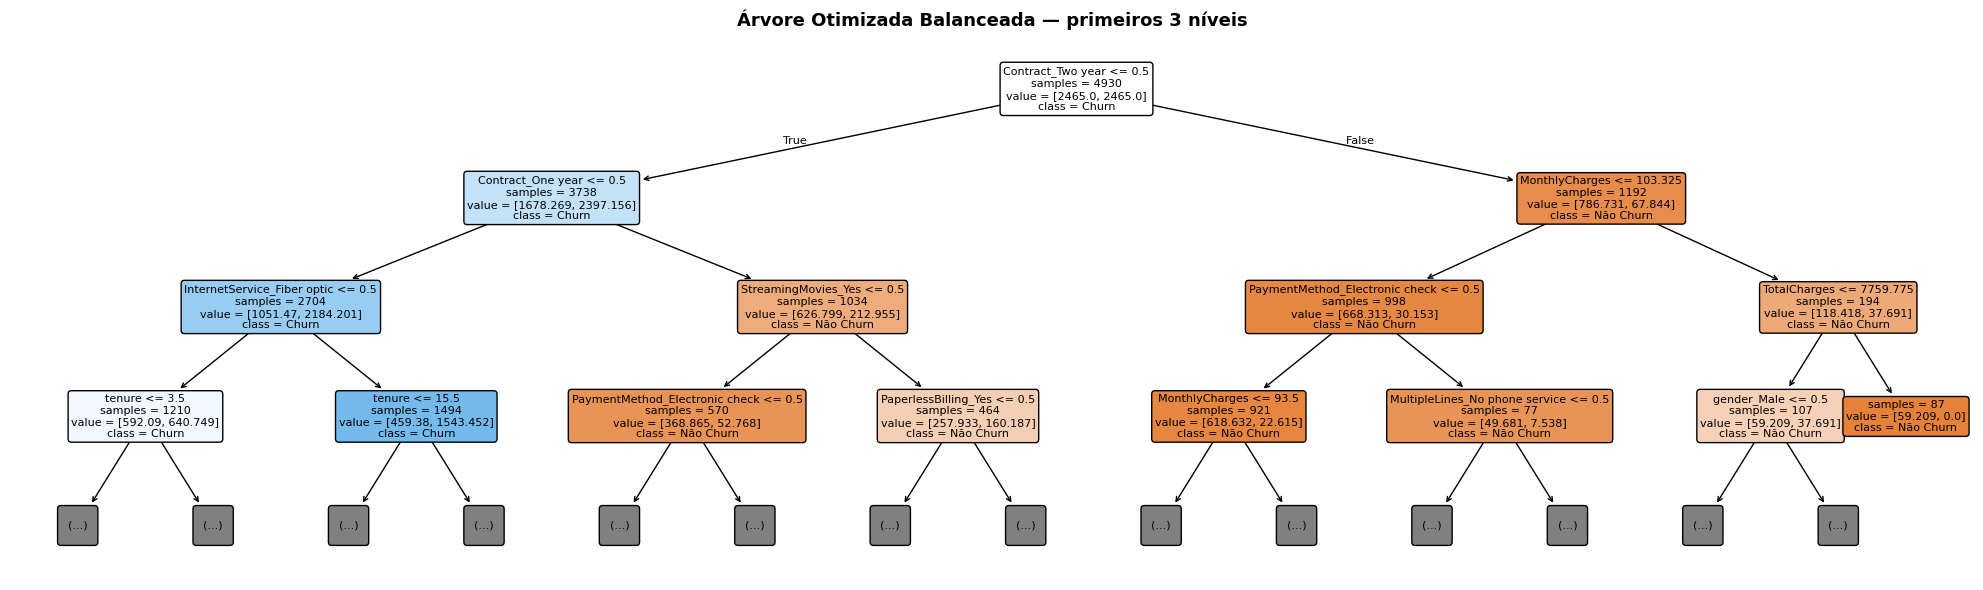

In [61]:
pipe_cv_bal = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), NUM_FEATURES),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
    ])),
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
])

grid_search_bal = GridSearchCV(
    estimator=pipe_cv_bal,
    param_grid={
        'dt__criterion':        ['gini', 'entropy'],
        'dt__max_depth':        [3, 5, 7, 10, 12],
        'dt__min_samples_leaf': [1, 5, 10, 20]
    },
    scoring='f1',
    cv=splitter,
    refit=True,
    n_jobs=-1
)
grid_search_bal.fit(x_train, y_train.values.ravel())
print('Árvore balanceada — melhores hiperparâmetros:', grid_search_bal.best_params_)
print(f'Melhor F1 médio (CV): {grid_search_bal.best_score_:.4f}')
yhat_test_opt_bal = grid_search_bal.best_estimator_.predict(x_test)

# visualização dos primeiros 3 níveis
dt_opt_bal_model = grid_search_bal.best_estimator_['dt']
cat_names_opt_bal = list(
    grid_search_bal.best_estimator_['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(CAT_FEATURES)
)
all_feat_names_opt_bal = NUM_FEATURES + cat_names_opt_bal

plt.figure(figsize=(20, 6))
plot_tree(
    dt_opt_bal_model,
    feature_names=all_feat_names_opt_bal,
    class_names=['Não Churn', 'Churn'],
    filled=True,
    max_depth=3,
    fontsize=8,
    impurity=False,
    rounded=True
)
plt.title('Árvore Otimizada Balanceada — primeiros 3 níveis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Análise do resultado da árvore otimizada e balanceada

Os nós estão separados em:
- **Laranja**: não-churn
- **Azul**: churn

Onde a intensidade da cor indica uma maior inclinação para cada classe.

O nó da raiz deixa explícito a regra mais importante: um contrato maior que 2 anos. O que faz sentido já que dificilmente um cliente pretende cancelar devido a multas ou até por confiar no serviço. 

Descendo para a esquerda temos mais uma vez a validação do contrato agora menor que 1 ano, onde se for maior leva ao não cancelamento. E ao cancelamento logo mais abaixo também referente a aquisição da fibra ótica que parece indicar um problema relacionando ao cancelamento.

Já a parte direita da árvore, apesar de não explicitar o tamanho do custo, pode indicar mais abaixo que os custos maiores podem influenciar o cancelamento. Outras features que se apresentam desse lado são múltiplos serviços e gênero, que até o terceiro nível não aparentam grande influência.

In [62]:
# ── Random Forest com balanceamento ────────────────────────────────
pipe_rf_bal = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), NUM_FEATURES),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
    ])),
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
])

random_search_bal = RandomizedSearchCV(
    estimator=pipe_rf_bal,
    param_distributions={
        'rf__n_estimators':     [100, 200, 300],
        'rf__max_depth':        [5, 7, 10, 15],
        'rf__min_samples_leaf': [1, 5, 10],
        'rf__max_features':     ['sqrt', 'log2']
    },
    n_iter=20,
    scoring='f1',
    cv=splitter,
    refit=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
random_search_bal.fit(x_train, y_train.values.ravel())
print('\nRandom Forest balanceada — melhores hiperparâmetros:', random_search_bal.best_params_)
print(f'Melhor F1 médio: {random_search_bal.best_score_:.4f}')
yhat_test_rf_bal = random_search_bal.best_estimator_.predict(x_test)


Random Forest balanceada — melhores hiperparâmetros: {'rf__n_estimators': 200, 'rf__min_samples_leaf': 5, 'rf__max_features': 'log2', 'rf__max_depth': 10}
Melhor F1 médio: 0.6335


=== Comparação de Modelos com balanceamento — Conjunto de Teste ===


,Accuracy,Precision,Recall,F1-Score
Perceptron,0.6687,0.4331,0.8021,0.5625
Árvore padrão,0.7241,0.4797,0.4635,0.4714
Árvore otimizada,0.7156,0.4782,0.7825,0.5936
Random Forest,0.7672,0.5428,0.7807,0.6404


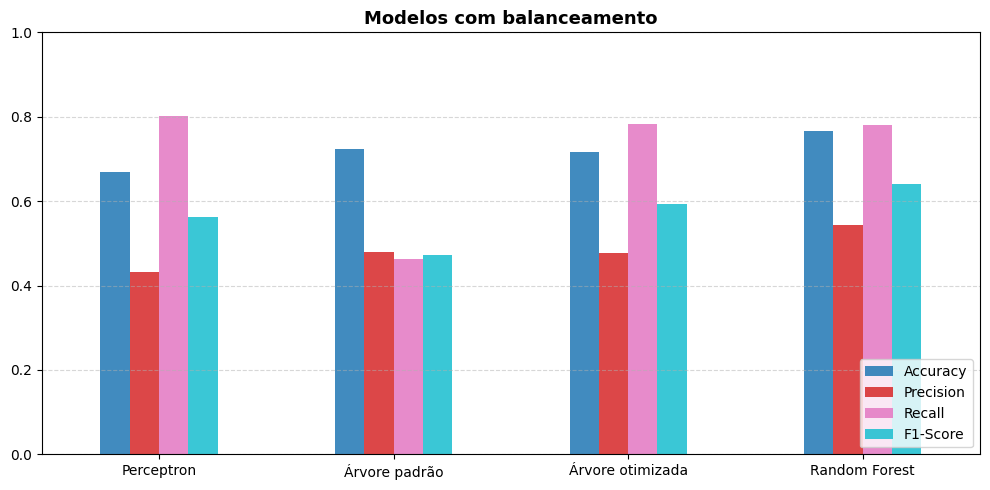

In [63]:

# ── Tabela comparativa de modelos balanceados ───────────────────────────
results_bal = pd.DataFrame({
    'Perceptron':        get_metrics(y_test_arr, yhat_test_perc_bal),
    'Árvore padrão':     get_metrics(y_test_arr, yhat_test_dt_bal),
    'Árvore otimizada':  get_metrics(y_test_arr, yhat_test_opt_bal),
    'Random Forest':     get_metrics(y_test_arr, yhat_test_rf_bal),
}).T

print('=== Comparação de Modelos com balanceamento — Conjunto de Teste ===')
display(results_bal)

# ── Gráfico de barras ─────────────────────────────────────────────────────────
ax = results_bal.plot(kind='bar', figsize=(10, 5), rot=0, colormap='tab10', alpha=0.85)
ax.set_title('Modelos com balanceamento', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


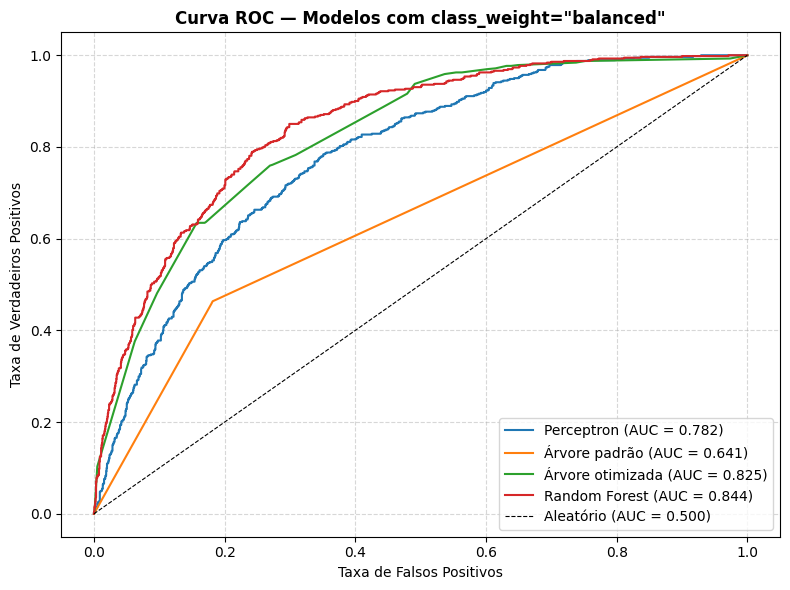

In [64]:
from sklearn.metrics import roc_curve, auc

scores_perc   = pipeline_perc_bal.decision_function(x_test)
scores_dt     = pipeline_dt_bal.predict_proba(x_test)[:, 1]
scores_dt_opt = grid_search_bal.best_estimator_.predict_proba(x_test)[:, 1]
scores_rf     = random_search_bal.best_estimator_.predict_proba(x_test)[:, 1]

modelos = {
    'Perceptron':       scores_perc,
    'Árvore padrão':    scores_dt,
    'Árvore otimizada': scores_dt_opt,
    'Random Forest':    scores_rf,
}

fig, ax = plt.subplots(figsize=(8, 6))

for nome, scores in modelos.items():
    fpr, tpr, _ = roc_curve(y_test_arr, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{nome} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Aleatório (AUC = 0.500)')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — Modelos com class_weight="balanced"', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Análise de resultados

A introdução do balanceamento de classes sacrificou um pouco a Acurácia e a Precisão geral do Random Forest, mas aumentou significativamente o Recall e o F1-Score. É possível ver que apesar dos ruídos na curva ROC ainda assim o Random Forest foi melhor que os outros modelos.

Ainda é possível melhorar utilizando o XGBoost para tentar corrigir os erros e diminuir o viés da classe dominante. 